# import libraries


In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
import warnings
# This tells Jupyter to hide harmless UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

# Exploration

In [104]:
df = pd.read_csv("cleaned_cyber_insurance_data.csv")
print(df.shape)
df.head()

(100000, 16)


,industry_sector,annual_revenue,years_in_operation,hq_location,pii_count,pci_data_flag,phi_data_flag,cloud_adoption_pct,subdomain_count,is_claim_filed,mfa_status,edr_deployed,patch_velocity,backup_type,training_freq,pen_test_age
0,Finance,1.158365e+08,8,UK,98733,1,0,58.49,468,0,1,1,65,Cloud-only,2,21
1,Education,1.596657e+09,5,Canada,338734,0,0,79.02,362,1,0,0,114,Cloud-only,4,32
2,Technology,2.387986e+07,11,UK,12752,0,0,73.64,360,0,1,1,11,Cloud-only,2,14
3,Manufacturing,2.406713e+06,10,Canada,2106,0,0,97.88,120,1,0,0,53,Offline,1,6
4,Healthcare,2.189112e+08,35,UK,935436,0,1,28.95,236,1,0,1,80,Offline,0,9


In [105]:
print(df["is_claim_filed"].value_counts())

is_claim_filed
0    64854
1    35146
Name: count, dtype: int64


In [106]:
majority_class_prop, minority_class_prop = df["is_claim_filed"].value_counts(normalize=True)
print(majority_class_prop, minority_class_prop)

0.64854 0.35146


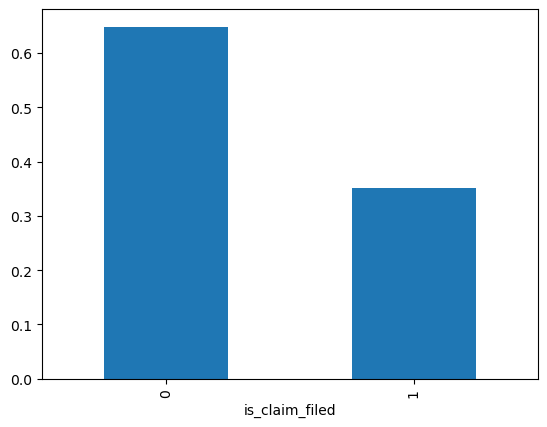

In [107]:
df["is_claim_filed"].value_counts(normalize=True).plot(kind="bar");

In [108]:
df.select_dtypes("object").nunique()

industry_sector    6
hq_location        5
backup_type        3
dtype: int64

In [109]:
# Create pivot table
industry_pivot = pd.pivot_table(
    df, index="industry_sector", values="is_claim_filed", aggfunc="mean"
).sort_values(by="is_claim_filed")
industry_pivot

,is_claim_filed
industry_sector,
Technology,0.214724
Finance,0.258074
Retail,0.355538
Manufacturing,0.355609
Education,0.360269
Healthcare,0.571200


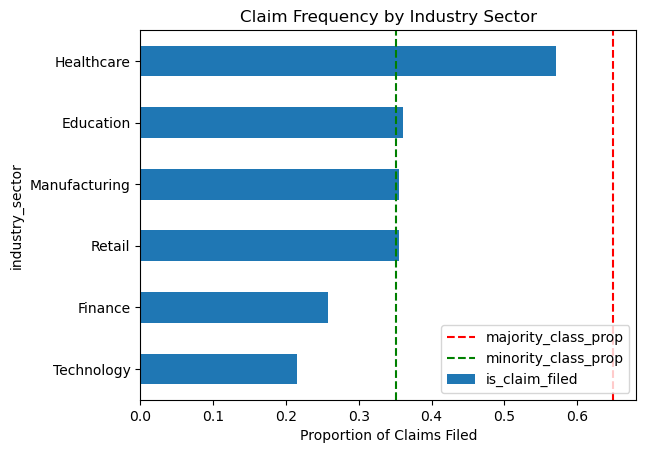

In [110]:
# Plot bar chart of `foundation_pivot`
industry_pivot.plot(kind="barh")
plt.axvline(
    majority_class_prop,linestyle="--",color="red", label="majority_class_prop"
)
plt.axvline(
    minority_class_prop,linestyle="--",color="green", label="minority_class_prop"
)
plt.legend(loc="lower right")
plt.xlabel("Proportion of Claims Filed")
plt.title("Claim Frequency by Industry Sector");

# Build Model

## Split

In [111]:
target = "is_claim_filed"
X = df.drop(target, axis=1)
y = df[target]

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80000, 15), (20000, 15), (80000,), (20000,))

In [113]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=.2, random_state=42)
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape

((64000, 15), (16000, 15), (20000, 15), (64000,), (16000,))

## Baseline

In [114]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.65


In [124]:
 # Build Model
model = make_pipeline(
    OrdinalEncoder(),
    SimpleImputer(),
    DecisionTreeClassifier(random_state=42, max_depth=4)
)

# Fit model to training data
model.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('simpleimputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,mapping,"[{'col': 'industry_sector', 'data_type': dtype('O'), 'mapping': Retail ...2 dtype: int64}, {'col': 'hq_location', 'data_type': dtype('O'), 'mapping': USA ...2 dtype: int64}, ...]"
,cols,"['industry_sector', 'hq_location', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [125]:
acc_train = accuracy_score(y_train,model.predict(X_train))
acc_val = model.score(X_val,y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))

Training Accuracy: 0.78
Validation Accuracy: 0.77


In [126]:
tree_depth = model.named_steps['decisiontreeclassifier'].get_depth()
print("Tree Depth:", tree_depth)

Tree Depth: 4


In [127]:
depth_hyperparams = range(1,50,2)

In [128]:
training_acc = []
validation_acc = []

for d in depth_hyperparams:
    # Create model with `max_depth` of `d`
    test_model = make_pipeline(
        OrdinalEncoder(),
        DecisionTreeClassifier(max_depth=d ,random_state=42)
        )
    
    # Fit model to training data
    test_model.fit(X_train, y_train)
    # Calculate training accuracy score and append to `training_acc`
    acc_train = accuracy_score(y_train,test_model.predict(X_train))
    training_acc.append(acc_train)
    # Calculate validation accuracy score and append to `training_acc`
    acc_val = test_model.score(X_val,y_val)
    validation_acc.append(acc_val)

print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.71253125, 0.76828125, 0.7889375]
Validation Accuracy Scores: [0.7150625, 0.7695625, 0.78625]


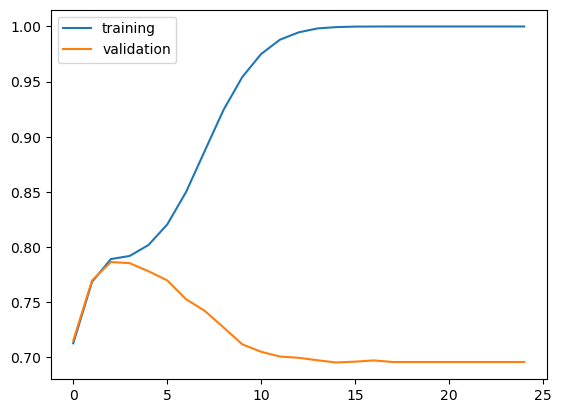

In [129]:
# Plot `depth_hyperparams`, `training_acc`
fig,ax = plt.subplots()
ax.plot(training_acc,label="training")
ax.plot(validation_acc, label="validation")
plt.legend();

In [130]:
test_acc = model.score(X_test,y_test)
print("Test Accuracy:", round(test_acc, 2))

Test Accuracy: 0.78


## Communicate

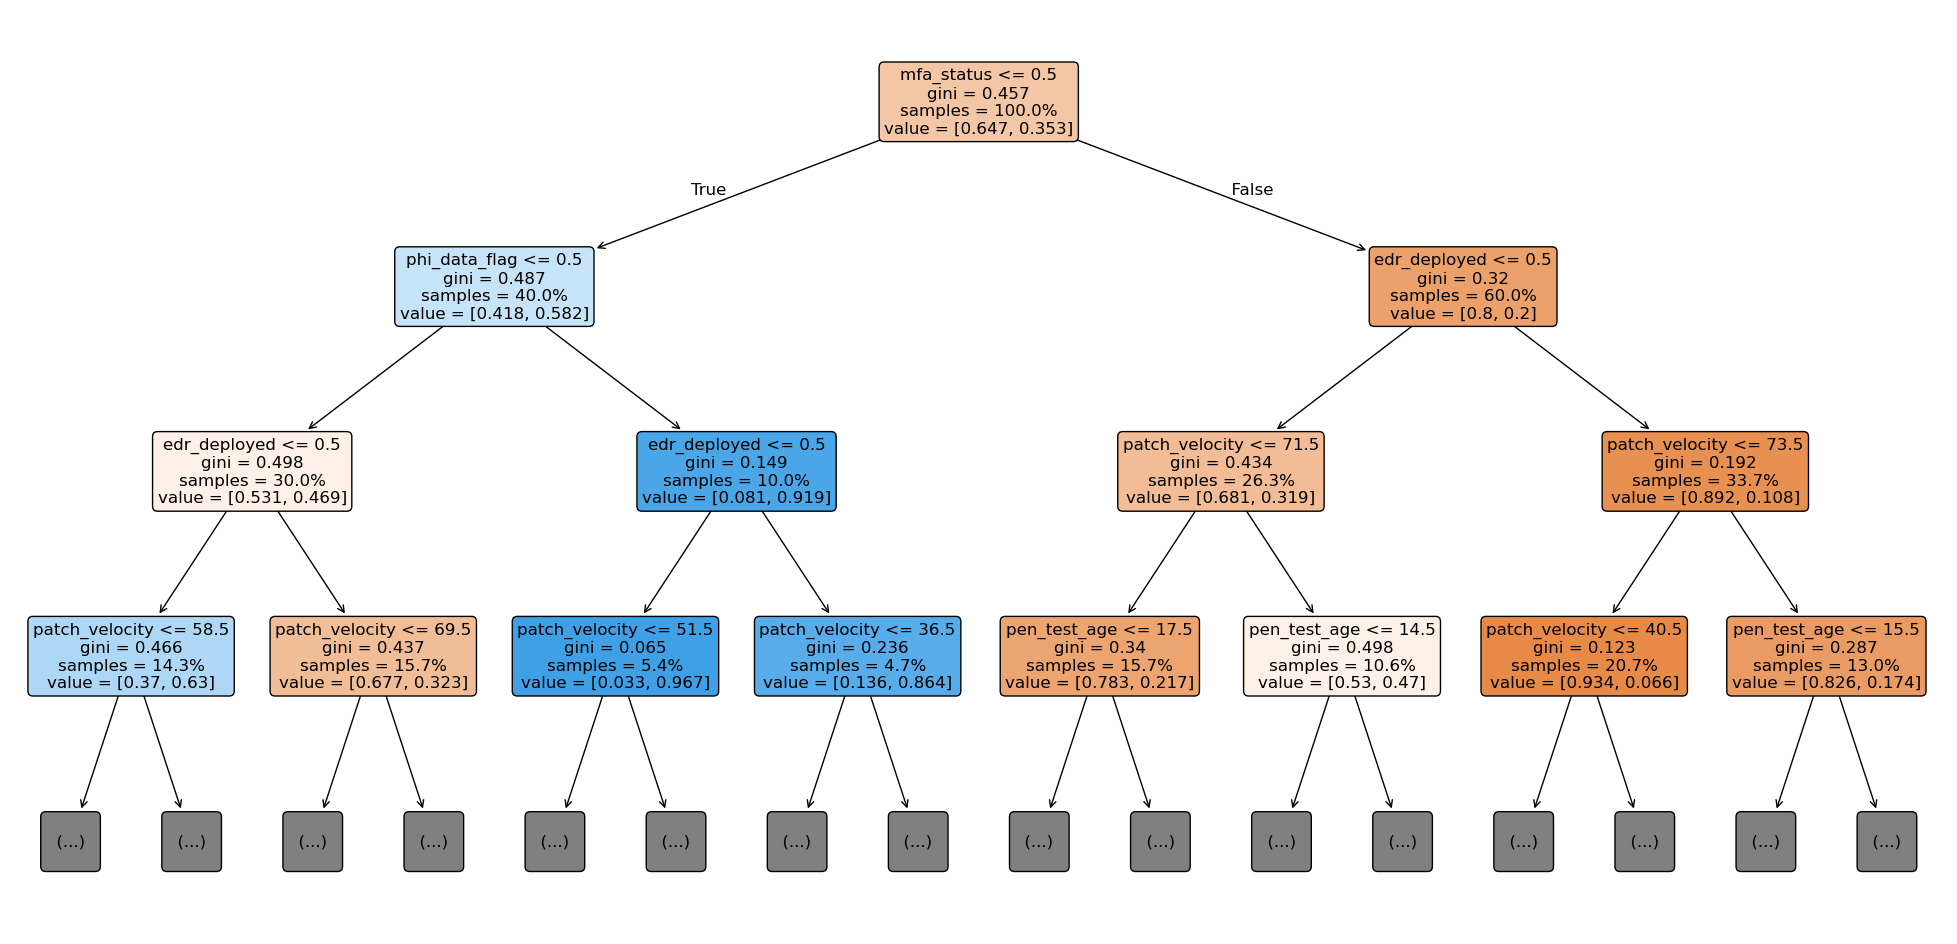

In [131]:
# Create larger figure
fig, ax = plt.subplots(figsize=(25, 12))
# Plot tree
plot_tree(
    decision_tree = model.named_steps['decisiontreeclassifier'],
    feature_names = X_train.columns.to_list(),
    filled=True,  # Color leaf with class
    rounded=True,  # Round leaf edges
    proportion=True,  # Display proportion of classes in leaf
    max_depth=3,  # Only display first 3 levels
    fontsize=12,  # Enlarge font
    ax=ax,  # Place in figure axis
);

In [132]:
features = X_train.columns
importances = model.named_steps['decisiontreeclassifier'].feature_importances_

print("Features:", features[:3])
print("Importances:", importances[:3])

Features: Index(['industry_sector', 'annual_revenue', 'years_in_operation'], dtype='object')
Importances: [0. 0. 0.]


In [133]:
feat_imp = pd.Series(importances, index=features).sort_values()
feat_imp.head()

industry_sector       0.0
annual_revenue        0.0
years_in_operation    0.0
hq_location           0.0
pii_count             0.0
dtype: float64

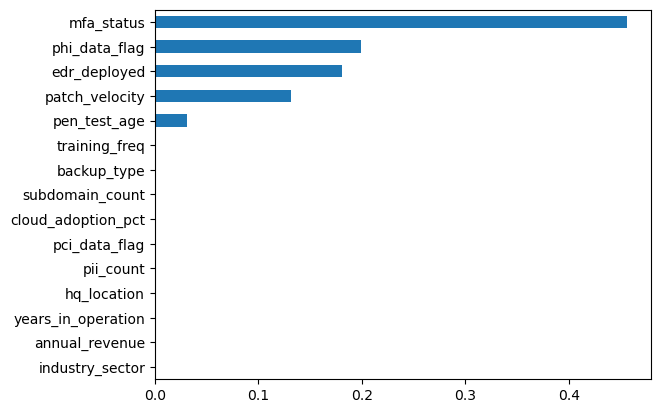

In [134]:
# Create horizontal bar chart
feat_imp.plot(kind="barh");

In [136]:
claim_by_location = df.groupby("hq_location")["is_claim_filed"].mean().sort_values(ascending=False).to_frame()
claim_by_location

,is_claim_filed
hq_location,
UK,0.355203
Germany,0.353918
USA,0.353690
Canada,0.349603
Australia,0.344897


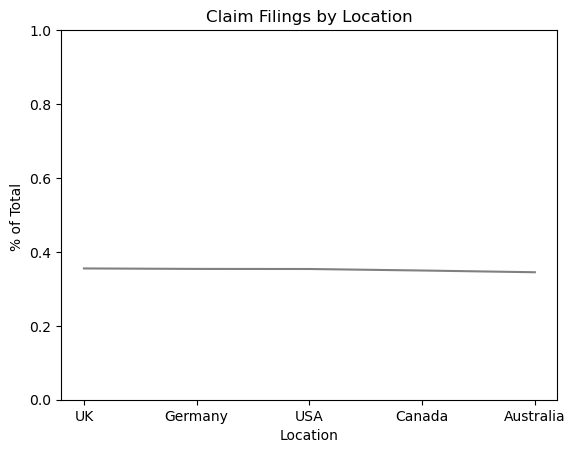

In [137]:
# Plot line
plt.plot(claim_by_location.values, color="gray")
plt.xticks(range(len(claim_by_location)), labels=claim_by_location.index)
plt.yticks(np.arange(0,1.1,.2))
plt.xlabel("Location")
plt.ylabel("% of Total ")
plt.title("Claim Filings by Location");

In [139]:
claim_by_location["Cloud-only"]= (
    df[df["backup_type"] == "Cloud-only"].groupby("hq_location")["is_claim_filed"].count()
    / df.groupby("hq_location")["is_claim_filed"].count()
).fillna(0)
claim_by_location

,is_claim_filed,Cloud-only
hq_location,,
UK,0.355203,0.498203
Germany,0.353918,0.506533
USA,0.353690,0.509505
Canada,0.349603,0.494593
Australia,0.344897,0.499248


In [140]:
claim_by_location["Offline"]= (
    df[df["backup_type"] == "Offline"].groupby("hq_location")["is_claim_filed"].count()
    / df.groupby("hq_location")["is_claim_filed"].count()
).fillna(0)
claim_by_location	

,is_claim_filed,Cloud-only,Offline
hq_location,,,
UK,0.355203,0.498203,0.304524
Germany,0.353918,0.506533,0.298471
USA,0.353690,0.509505,0.295465
Canada,0.349603,0.494593,0.307738
Australia,0.344897,0.499248,0.302085


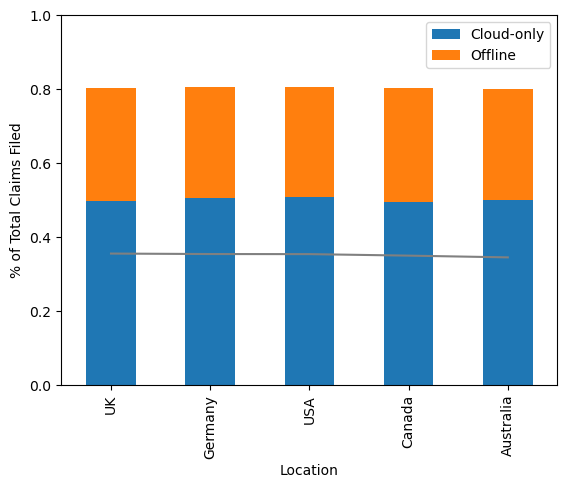

In [142]:
claim_by_location.drop(columns="is_claim_filed").plot(
    kind="bar",stacked=True
)
plt.plot(claim_by_location["is_claim_filed"].values, color="gray")
plt.xticks(range(len(claim_by_location)), labels=claim_by_location.index)
plt.yticks(np.arange(0,1.1,.2))
plt.xlabel("Location")
plt.ylabel("% of Total Claims Filed");